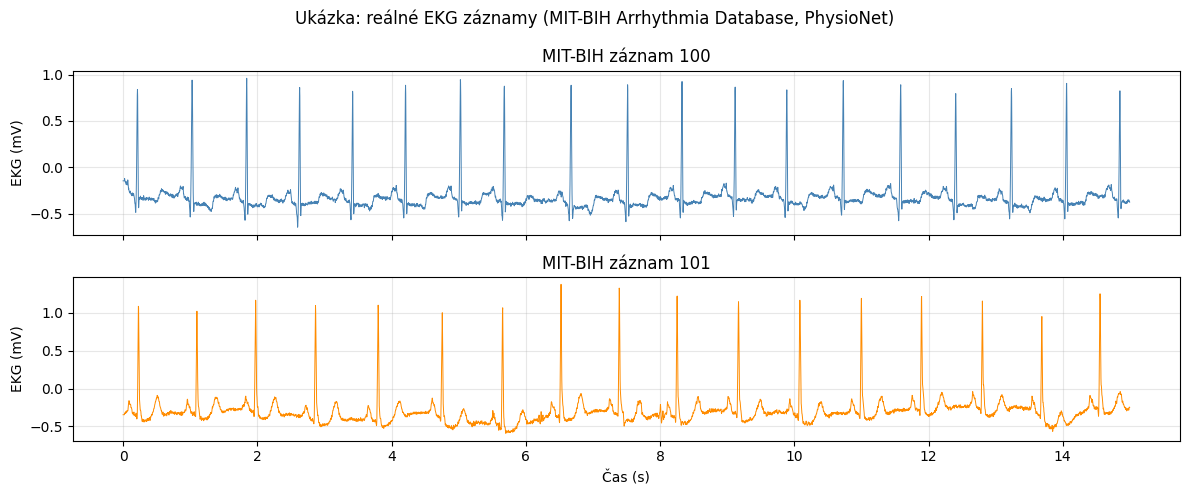

Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


In [1]:
# Ukázkové načtení a zobrazení dvou reálných EKG záznamů pomocí pevně zadané cesty
# Data z MIT-BIH Arrhythmia Database (PhysioNet), fs = 360 Hz
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

data_0 = np.loadtxt("data/ekg_real/mitbih_100.txt", skiprows=1)
data_1 = np.loadtxt("data/ekg_real/mitbih_101.txt", skiprows=1)
t0, ekg0 = data_0[:, 0], data_0[:, 1]
t1, ekg1 = data_1[:, 0], data_1[:, 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t0, ekg0, linewidth=0.7, color="steelblue")
ax1.set_ylabel("EKG (mV)")
ax1.set_title("MIT-BIH záznam 100")
ax1.grid(True, alpha=0.3)
ax2.plot(t1, ekg1, linewidth=0.7, color="darkorange")
ax2.set_xlabel("Čas (s)")
ax2.set_ylabel("EKG (mV)")
ax2.set_title("MIT-BIH záznam 101")
ax2.grid(True, alpha=0.3)
plt.suptitle("Ukázka: reálné EKG záznamy (MIT-BIH Arrhythmia Database, PhysioNet)")
plt.tight_layout()
plt.show()
print(f"Délka záznamu: {t0[-1]:.1f} s, vzorkovací frekvence: {1/(t0[1]-t0[0]):.0f} Hz")

Načteno 7 klidových a 6 zátěžových záznamů
Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


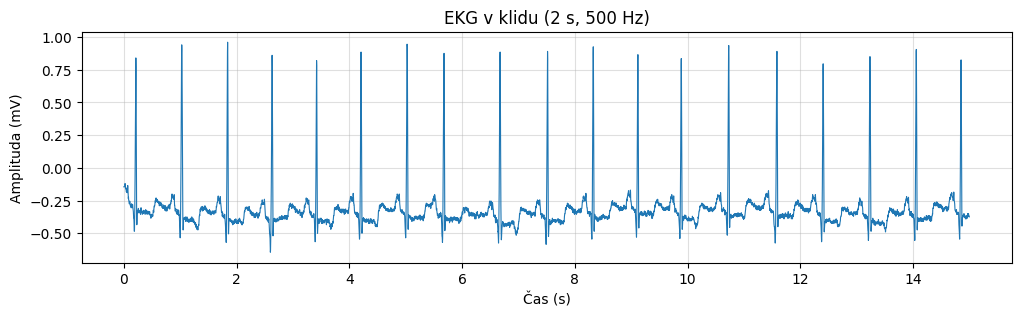

In [7]:
%matplotlib inline
import glob
import numpy as np
import matplotlib.pyplot as plt

# 1) Získej seznamy souborů
files_klid  = glob.glob("data/ekg_klid/*.txt")
files_zatez = glob.glob("data/ekg_zatez/*.txt")

# 2) Načti první klidový záznam a rozbal t a ekg
data0 = np.loadtxt(files_klid[0], skiprows=1)
t   = data0[:, 0]
ekg = data0[:, 1]

print(f"Načteno {len(files_klid)} klidových a {len(files_zatez)} zátěžových záznamů")
print(f"Délka záznamu: {t[-1]:.1f} s, vzorkovací frekvence: {1/(t[1]-t[0]):.0f} Hz")

# 3) Vykresli signál jako spojnicový graf s popsanými osami
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8)
ax.set_title("EKG v klidu (2 s, 500 Hz)")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Amplituda (mV)")
ax.grid(True, alpha=0.4)
plt.show()

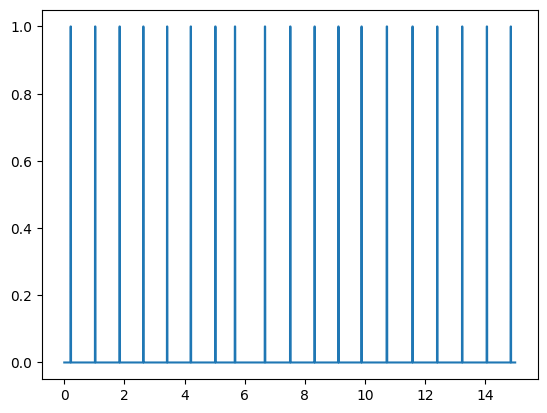

In [15]:
THRESHOLD = .5

above_threshold = ekg > THRESHOLD

fig, ax = plt.subplots()
ax.plot(t, above_threshold)

plt.show()


Nalezeno vrcholů: 19


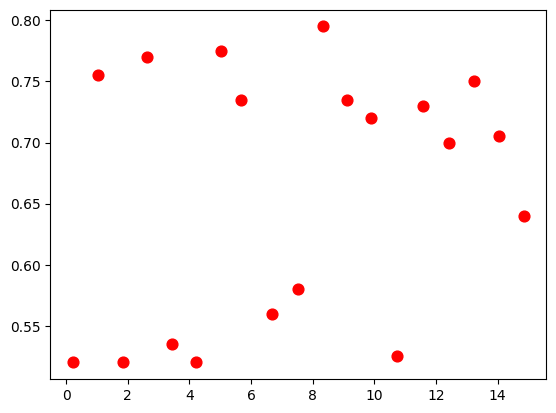

In [24]:
above_threshold_nums = above_threshold.astype(int)

peaks_idx = np.where(np.diff(above_threshold.astype(int)) == -1)[0]

print(f"Nalezeno vrcholů: {len(peaks_idx)}")

fig, ax = plt.subplots()
ax.scatter(t[peaks_idx], ekg[peaks_idx], color = "red", s = 60, zorder = 5)

plt.show()

In [26]:
time_peaks = t[peaks_idx]
rr_intervals = np.diff(time_peaks)
tf_bpm = 60 / rr_intervals.mean()

print(f"Průměrný R-R interval: {rr_intervals.mean():.3f} s")
print(f"Tepová frekvence: {tf_bpm:.1f} BPM")

Průměrný R-R interval: 0.813 s
Tepová frekvence: 73.8 BPM


In [ ]:
THRESHOLD = .5

def calculate_tf(filename: str) -> float:
    data = np.loadtxt(filename, skiprows=1)
    t = data[:, 0]
    ekg = data[:, 1]

Krátce komentuj:

1. Jak se klidová a zátěžová skupina liší v průměrné tepové frekvenci?
2. Objevil ses outlier? Odkud by mohl pocházet (reálná arytmie, šum, špatně zvolený práh)?
3. Proč je taková jednoduchá detekce (pevný práh + sestupná hrana) v praxi omezená? Co by bylo potřeba udělat pro robustnější detekci R-vrcholů (filtrace pásmovou propustí, adaptivní práh, Pan–Tompkinsův algoritmus)?
Sem napiš svou odpověď.

1. Zátěžová skupina má vyšší průměrnou tepovou frekvenci
2. Velký outlier se neobjevil. Outliery spůsobí nejčastěji šum, nesprávné měření nebo jiné faktory jako například arytmie
3. Můžeme použít například adaptivní práh, Pan-Tompkinsův algoritmus, atd.